<a href="https://colab.research.google.com/github/edu015u/Percepcion/blob/main/Colab_entrenamiento_rescate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenamiento de Red Neuronal Convolucional para detectar 3 clases (Ilesos,Heridos,Graves)
Equipo:07  Grupo: 001
Percepción


Se ejecutan las celdas en orden en Google Colab. El Notebook pide el Zip.

| Carpetas | Clase | Índice | Estado del LED |
| --- | --- | --- | --- |
| graves + graves_dia | grave | 0 | 3: rojo D10 |
| heridas + heridas_dia | herido | 1 | 2: naranja D9 |
| ilesas + ilesas_dia | ileso | 2 | 1: verde D8 |

La clase fondo no se utiliza. Se prepara un rechazo provisional por confianza y distancia a representaciones de las figuras de entrenamiento. Un rechazo envía 0 al Arduino y apaga los tres LEDs; una figura debe superar los filtros durante dos fotogramas seguidos para encender su LED.



## 1. Cargar el ZIP
Se selecciona el ZIP con las carpetas de las imágenes.

In [2]:
from google.colab import files
from pathlib import Path
import zipfile
import tempfile

subidos = files.upload()
zips = [nombre for nombre in subidos if nombre.lower().endswith('.zip')]
if len(zips) != 1:
    raise ValueError('Selecciona exactamente un ZIP del dataset.')
EXTRAIDO = Path(tempfile.mkdtemp(prefix='rescate_3clases_', dir='/content'))
with zipfile.ZipFile(zips[0]) as archivo:
    archivo.extractall(EXTRAIDO)
del subidos

CARPETA_A_CLASE = {
    'graves': 0, 'graves_dia': 0,
    'heridas': 1, 'heridas_dia': 1,
    'ilesas': 2, 'ilesas_dia': 2,
}
CLASES = ['grave', 'herido', 'ileso']
ESTADOS_LED = [3, 2, 1]
candidatos = [p for p in [EXTRAIDO, *EXTRAIDO.rglob('*')]
              if p.is_dir() and all((p / n).is_dir() for n in CARPETA_A_CLASE)]
if len(candidatos) != 1:
    raise ValueError('No se encontro una unica carpeta con graves, graves_dia, heridas, heridas_dia, ilesas e ilesas_dia.')
RAIZ = candidatos[0]
DESTINO = Path(tempfile.mkdtemp(prefix='salida_rescate_', dir='/content'))
print('Dataset:', RAIZ)
print('Archivos de salida:', DESTINO)

Saving dataset_pia_completo.zip to dataset_pia_completo.zip
Dataset: /content/rescate_3clases_pkkfpqr_/pia
Archivos de salida: /content/salida_rescate_9jeew159


## 2. Revisar las imágenes y separar por bloques de captura
No se copian fotos sobre otras: cada ruta conserva su carpeta de origen. Se descartan copias idénticas por contenido binario y se comprueba que no existan duplicados exactos con etiquetas diferentes.

Se reserva aproximadamente el 20% de los bloques de cada carpeta, manteniendo al menos uno para entrenar. Con dos ráfagas de 100 en una carpeta, una se usa para entrenar y otra para validar: en ese caso la división es 50/50. Una carpeta con una sola ráfaga se deja en entrenamiento y se indica que falta validar esa condición.

In [3]:
import hashlib
import re
import random
import math
import csv
from collections import Counter
from PIL import Image

SEMILLA = 123
FOTOS_POR_RAFAGA = 100
FRACCION_VALIDACION = 0.20
EXTENSIONES = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

def preparar_registros(raiz, carpeta_a_clase, bloque=100, semilla=123):
    registros, vistos, duplicadas = [], {}, 0
    for carpeta, etiqueta in carpeta_a_clase.items():
        rutas = sorted(p for p in (raiz / carpeta).rglob('*')
                       if p.is_file() and p.suffix.lower() in EXTENSIONES)
        if not rutas:
            raise ValueError(f'No hay fotos en {carpeta}.')
        for ruta in rutas:
            with Image.open(ruta) as imagen:
                imagen.verify()
            huella = hashlib.sha256(ruta.read_bytes()).hexdigest()
            if huella in vistos:
                if vistos[huella] != etiqueta:
                    raise ValueError(f'Una misma imagen tiene dos clases: {ruta}')
                duplicadas += 1
                continue
            vistos[huella] = etiqueta
            numero = re.fullmatch(r'(.*?)(\d+)', ruta.stem)
            if numero is None or int(numero.group(2)) < 1:
                raise ValueError(f'Falta contador final de captura en {ruta.name}; revisa la agrupacion.')
            identificador = (int(numero.group(2)) - 1) // bloque
            grupo = f'{carpeta}/{ruta.parent.relative_to(raiz / carpeta)}/{numero.group(1)}bloque_{identificador:04d}'
            registros.append({'ruta': str(ruta), 'clase': etiqueta, 'carpeta': carpeta,
                              'grupo': grupo, 'sha256': huella})
    train, val = [], []
    for posicion, carpeta in enumerate(carpeta_a_clase):
        filas = [r for r in registros if r['carpeta'] == carpeta]
        grupos = sorted({r['grupo'] for r in filas})
        if not grupos:
            raise ValueError(f'{carpeta} quedo vacia despues de retirar copias identicas.')
        random.Random(semilla + posicion).shuffle(grupos)
        if len(grupos) >= 2:
            n_val = min(len(grupos) - 1, max(1, math.ceil(FRACCION_VALIDACION * len(grupos))))
            grupos_val = set(grupos[:n_val])
        else:
            grupos_val = set()
            print(f'AVISO: {carpeta} tiene una sola rafaga; se usa para entrenar, sin validar esa condicion.')
        train.extend(r for r in filas if r['grupo'] not in grupos_val)
        val.extend(r for r in filas if r['grupo'] in grupos_val)
    if {r['clase'] for r in train} != {0, 1, 2} or {r['clase'] for r in val} != {0, 1, 2}:
        raise ValueError('Falta una clase en entrenamiento o validacion. Hace falta otra captura independiente de esa clase.')
    assert not ({r['grupo'] for r in train} & {r['grupo'] for r in val})
    assert not ({r['sha256'] for r in train} & {r['sha256'] for r in val})
    print('Copias exactas retiradas:', duplicadas)
    return train, val

registros_train, registros_val = preparar_registros(RAIZ, CARPETA_A_CLASE,
                                                   FOTOS_POR_RAFAGA, SEMILLA)
print('Carpeta | Entrenamiento | Validacion')
for carpeta in CARPETA_A_CLASE:
    print(carpeta, sum(r['carpeta'] == carpeta for r in registros_train),
          sum(r['carpeta'] == carpeta for r in registros_val))
print('Clases finales:', CLASES)
print('Total:', len(registros_train), 'entrenamiento y', len(registros_val), 'validacion')
with (DESTINO / 'division_dataset.csv').open('w', newline='', encoding='utf-8') as archivo:
    escritor = csv.DictWriter(archivo, fieldnames=['ruta', 'clase', 'carpeta', 'grupo', 'sha256', 'subconjunto'])
    escritor.writeheader()
    for nombre, registros in [('entrenamiento', registros_train), ('validacion', registros_val)]:
        for fila in registros:
            escritor.writerow({**fila, 'subconjunto': nombre})

Copias exactas retiradas: 0
Carpeta | Entrenamiento | Validacion
graves 100 100
graves_dia 200 100
heridas 100 100
heridas_dia 200 100
ilesas 100 100
ilesas_dia 200 100
Clases finales: ['grave', 'herido', 'ileso']
Total: 900 entrenamiento y 600 validacion


## 3. Cargar RGB sin normalización externa
Las fotos se guardaron con cv2.imwrite y se cargan como imágenes RGB convencionales.

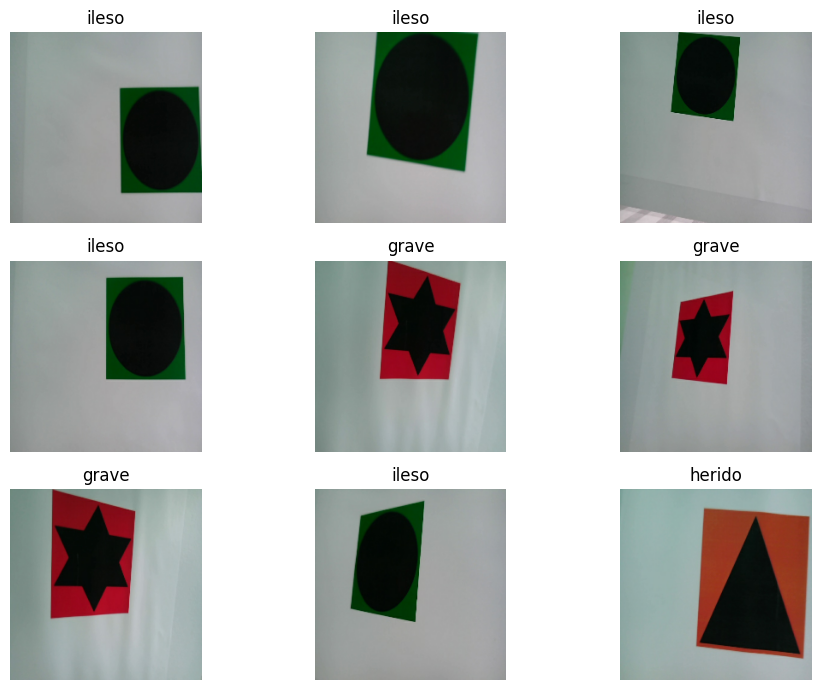

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(SEMILLA)
TAMANO = (224, 224)
LOTE = 32

def leer_imagen(ruta, etiqueta):
    imagen = tf.io.decode_image(tf.io.read_file(ruta), channels=3, expand_animations=False)
    imagen.set_shape([None, None, 3])
    imagen = tf.image.resize(tf.cast(imagen, tf.float32), TAMANO, method='bilinear')
    return imagen, etiqueta

def crear_dataset(registros, mezclar=False):
    rutas = [r['ruta'] for r in registros]
    etiquetas = [r['clase'] for r in registros]
    ds = tf.data.Dataset.from_tensor_slices((rutas, etiquetas))
    if mezclar:
        ds = ds.shuffle(len(registros), seed=SEMILLA, reshuffle_each_iteration=True)
    ds = ds.map(leer_imagen, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(LOTE).prefetch(tf.data.AUTOTUNE)

train_ds = crear_dataset(registros_train, mezclar=True)
train_ordenado = crear_dataset(registros_train)
val_ds = crear_dataset(registros_val).cache()

imagenes, etiquetas = next(iter(train_ds))
plt.figure(figsize=(10, 7))
for i in range(min(9, len(imagenes))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(np.clip(imagenes[i].numpy(), 0, 255).astype(np.uint8))
    plt.title(CLASES[int(etiquetas[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Entrenar MobileNetV2 con tres clases
La conversión a -1..1 queda dentro del modelo. Los aumentos geométricos se aplican solo al entrenamiento. La segunda salida que se exportará contiene características visuales para el filtro.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.9011 - loss: 0.3061 - val_accuracy: 0.9867 - val_loss: 0.0615 - learning_rate: 0.0010
Epoch 2/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9944 - loss: 0.0430 - val_accuracy: 0.9983 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 3/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9989 - loss: 0.0213 - val_accuracy: 1.0000 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 4/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9989 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 5/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 1.0000 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 6/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 7/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s

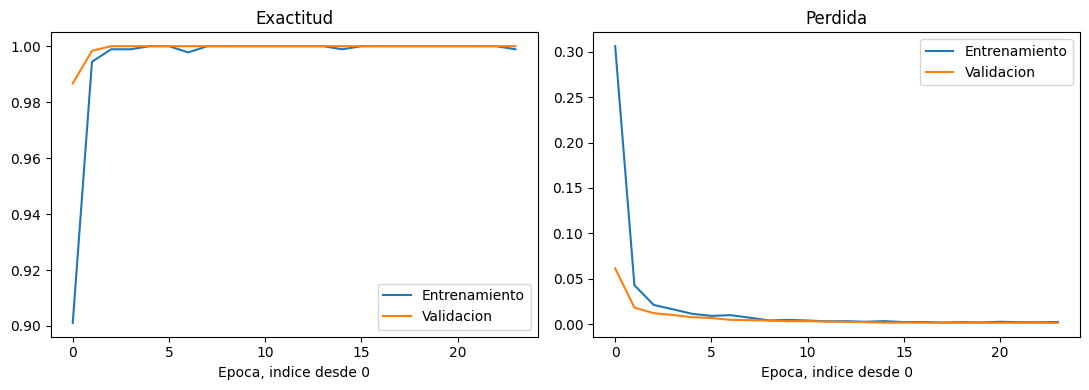

In [6]:
aumento = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.035),
    tf.keras.layers.RandomTranslation(0.08, 0.08),
    tf.keras.layers.RandomZoom(0.10),
], name='aumento')
base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base.trainable = False

entrada = tf.keras.Input(shape=(224, 224, 3), dtype=tf.float32, name='imagen_rgb')
x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1.0)(entrada)
x = base(x, training=False)
caracteristicas = tf.keras.layers.GlobalAveragePooling2D(name='caracteristicas')(x)
x = tf.keras.layers.Dropout(0.2)(caracteristicas)
probabilidades = tf.keras.layers.Dense(3, activation='softmax', name='probabilidades')(x)
clasificador = tf.keras.Model(entrada, probabilidades)
extractor = tf.keras.Model(entrada, caracteristicas)
modelo_exportar = tf.keras.Model(entrada, {'probabilidades': probabilidades,
                                         'caracteristicas': caracteristicas})

entrada_train = tf.keras.Input(shape=(224, 224, 3), dtype=tf.float32)
modelo_entrenamiento = tf.keras.Model(entrada_train, clasificador(aumento(entrada_train)))
modelo_entrenamiento.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = modelo_entrenamiento.fit(
    train_ds, validation_data=val_ds, epochs=25,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
    ])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metrica, titulo in zip(axes, ['accuracy', 'loss'], ['Exactitud', 'Perdida']):
    ax.plot(history.history[metrica], label='Entrenamiento')
    ax.plot(history.history['val_' + metrica], label='Validacion')
    ax.set_title(titulo)
    ax.set_xlabel('Epoca, indice desde 0')
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Calibrar el rechazo provisional
Se calcula una representación promedio por carpeta de origen para conservar referencias de día y noche. La imagen debe parecerse a una referencia de la clase elegida y superar una confianza inicial del 90%.

El límite de distancia es el percentil 90 de distancias de figuras conocidas de validación.

In [8]:
PROBABILIDAD_MINIMA = 0.90
PERCENTIL_DISTANCIA = 0.90
FOTOGRAMAS_CONSECUTIVOS = 2

def normalizar_filas(matriz):
    matriz = np.asarray(matriz, dtype=np.float32)
    normas = np.linalg.norm(matriz, axis=1, keepdims=True)
    if not np.all(np.isfinite(matriz)) or np.any(normas < 1e-8):
        raise ValueError('Hay imagenes sin caracteristicas validas. Revisa capturas y modelo.')
    return matriz / normas

f_train = normalizar_filas(extractor.predict(train_ordenado, verbose=1))
f_val = normalizar_filas(extractor.predict(val_ds, verbose=1))
p_val = clasificador.predict(val_ds, verbose=1)
y_val = np.asarray([r['clase'] for r in registros_val], dtype=np.int32)
carpetas_train = np.asarray([r['carpeta'] for r in registros_train])
prototipos, etiquetas_prototipos = [], []
for carpeta, etiqueta in CARPETA_A_CLASE.items():
    filas = f_train[carpetas_train == carpeta]
    if len(filas) == 0:
        raise ValueError(f'No hay entrenamiento para {carpeta}.')
    centro = normalizar_filas(filas.mean(axis=0, keepdims=True))[0]
    prototipos.append(centro)
    etiquetas_prototipos.append(etiqueta)
prototipos = np.asarray(prototipos, dtype=np.float32)
etiquetas_prototipos = np.asarray(etiquetas_prototipos, dtype=np.int32)

# Distancia coseno a la referencia mas cercana de cada clase.
distancias = np.column_stack([
    np.clip(1.0 - np.max(f_val @ prototipos[etiquetas_prototipos == c].T, axis=1), 0.0, 2.0)
    for c in range(3)
])
limites = np.asarray([
    max(1e-4, float(np.quantile(distancias[y_val == c, c], PERCENTIL_DISTANCIA)))
    for c in range(3)
], dtype=np.float32)

predichas = np.argmax(p_val, axis=1)
confianzas = np.max(p_val, axis=1)
aceptadas = ((confianzas >= PROBABILIDAD_MINIMA)
             & (distancias[np.arange(len(y_val)), predichas] <= limites[predichas]))
matriz = tf.math.confusion_matrix(y_val, predichas, num_classes=3).numpy()
print('Matriz SIN filtro: filas reales, columnas predichas. Orden:', CLASES)
print(matriz)
for c, nombre in enumerate(CLASES):
    seleccion = y_val == c
    total = int(seleccion.sum())
    aciertos = int(np.sum(seleccion & (predichas == c)))
    correctas_aceptadas = int(np.sum(seleccion & aceptadas & (predichas == c)))
    falsas_aceptadas = int(np.sum(seleccion & aceptadas & (predichas != c)))
    rechazadas = int(np.sum(seleccion & ~aceptadas))
    print(f'{nombre}: {total} fotos; {aciertos} aciertos sin filtro; '
          f'{correctas_aceptadas} correctas aceptadas; {falsas_aceptadas} incorrectas aceptadas; '
          f'{rechazadas} rechazadas; limite={limites[c]:.4f}')
print('Las incorrectas aceptadas son confusiones ENTRE figuras; no errores sobre fondos desconocidos.')
print('El requisito temporal de tres fotogramas se aplica en la camara, no a fotos sueltas de validacion.')

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 660ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 720ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step
Matriz SIN filtro: filas reales, columnas predichas. Orden: ['grave', 'herido', 'ileso']
[[200   0   0]
 [  0 200   0]
 [  0   0 200]]
grave: 200 fotos; 200 aciertos sin filtro; 180 correctas aceptadas; 0 incorrectas aceptadas; 20 rechazadas; limite=0.1338
herido: 200 fotos; 200 aciertos sin filtro; 180 correctas aceptadas; 0 incorrectas aceptadas; 20 rechazadas; limite=0.1149
ileso: 200 fotos; 200 aciertos sin filtro; 180 correctas aceptadas; 0 incorrectas aceptadas; 20 rechazadas; limite=0.1304
Las incorrectas aceptadas son confusiones ENTRE figuras; no errores sobre fondos desconocidos.
El requisito temporal de tres fotogramas se aplica en la camara, no a fotos sueltas de validacion.


## 6. Exportar modelo y configuración juntos
Se conserva float32. La firma exportada recibe una imagen RGB de 224×224 con valores 0..255. La configuración guarda el orden de clases, el filtro y una huella que vincula el JSON con este TFLite.

In [9]:
import json

modelo_exportar.export(
    str(DESTINO / 'saved_model'),
    input_signature=[tf.TensorSpec(shape=(1, 224, 224, 3), dtype=tf.float32)])
converter = tf.lite.TFLiteConverter.from_saved_model(str(DESTINO / 'saved_model'))
contenido_tflite = converter.convert()
ruta_modelo = DESTINO / 'modelo_rescate.tflite'
ruta_modelo.write_bytes(contenido_tflite)

interpreter = tf.lite.Interpreter(model_path=str(ruta_modelo))
interpreter.allocate_tensors()
ent = interpreter.get_input_details()[0]
salidas = interpreter.get_output_details()
s_prob = [s for s in salidas if tuple(s['shape']) == (1, 3)]
s_feat = [s for s in salidas if tuple(s['shape']) == (1, prototipos.shape[1])]
assert len(s_prob) == len(s_feat) == 1, 'No se identificaron las dos salidas.'
s_prob, s_feat = s_prob[0], s_feat[0]
assert ent['dtype'] == s_prob['dtype'] == s_feat['dtype'] == np.float32

# Verificar conversion en una imagen, no medir precision real con este chequeo.
imagenes, _ = next(iter(val_ds))
muestra = imagenes[:1].numpy().astype(np.float32)
referencia = modelo_exportar(muestra, training=False)
interpreter.set_tensor(ent['index'], muestra)
interpreter.invoke()
for clave, detalle in [('probabilidades', s_prob), ('caracteristicas', s_feat)]:
    resultado = interpreter.get_tensor(detalle['index'])
    esperado = referencia[clave].numpy()
    print(clave, 'diferencia maxima:', float(np.max(np.abs(resultado - esperado))))
    assert np.allclose(resultado, esperado, atol=1e-3, rtol=1e-3), 'Revisar conversion.'

config = {
    'schema_version': 2,
    'class_names': CLASES,
    'led_states': ESTADOS_LED,
    'input_color': 'RGB',
    'input_range': [0, 255],
    'normalization_inside_model': 'Rescaling(1/127.5, offset=-1)',
    'model_sha256': hashlib.sha256(contenido_tflite).hexdigest(),
    'outputs': {'probabilities_index': int(s_prob['index']),
                'features_index': int(s_feat['index'])},
    'rejection': {
        'method': 'class_cosine_prototypes_v1',
        'prototypes': prototipos.tolist(),
        'prototype_labels': etiquetas_prototipos.tolist(),
        'distance_limits': limites.tolist(),
        'probability_min': PROBABILIDAD_MINIMA,
        'consecutive_frames': FOTOGRAMAS_CONSECUTIVOS,
        'calibration_quantile': PERCENTIL_DISTANCIA,
        'calibrated_with_negatives': False,
    },
}
ruta_json = DESTINO / 'clases_rescate.json'
ruta_json.write_text(json.dumps(config, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
ruta_zip = DESTINO / 'rescate_3clases_dia_noche.zip'
with zipfile.ZipFile(ruta_zip, 'w', zipfile.ZIP_DEFLATED) as archivo:
    for ruta in (ruta_modelo, ruta_json, DESTINO / 'division_dataset.csv'):
        archivo.write(ruta, ruta.name)
files.download(str(ruta_zip))

Saved artifact at '/content/salida_rescate_9jeew159/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 224, 224, 3), dtype=tf.float32, name=None)
Output Type:
  Dict[['probabilidades', TensorSpec(shape=(1, 3), dtype=tf.float32, name=None)], ['caracteristicas', TensorSpec(shape=(1, 1280), dtype=tf.float32, name=None)]]
Captures:
  135593663738704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663726224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663727760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663738512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663726416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663422224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663421840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663422032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135593663733904: TensorSpec(shape=(),

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


probabilidades diferencia maxima: 1.8335413187742233e-09
caracteristicas diferencia maxima: 1.8358230590820312e-05


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>